# Step 1

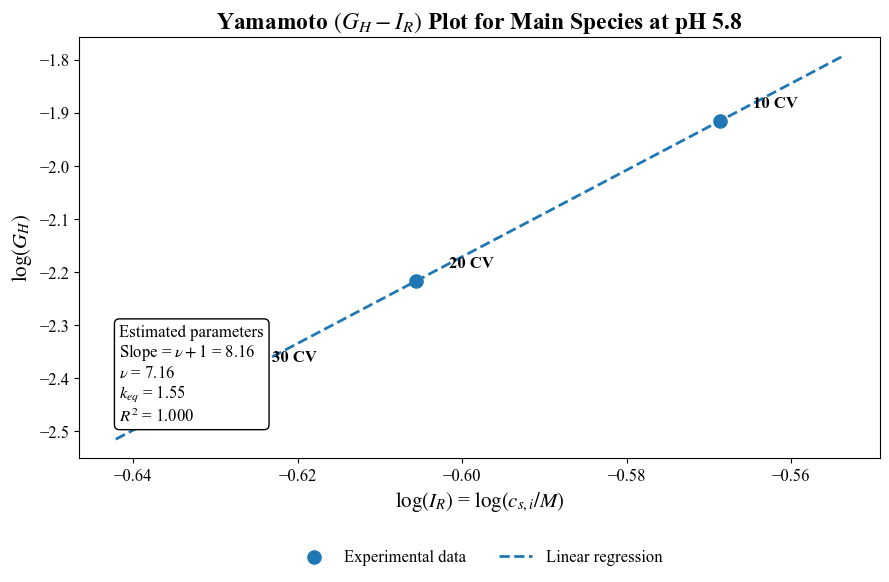

In [1]:
 import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -----------------------------
# Representative Yamamoto data
# -----------------------------
gradient_cv = np.array([10, 20, 30])
GH = np.array([0.01215, 0.00608, 0.00405])
IR = np.array([0.270, 0.248, 0.236])   # elution salt concentration, M

log_GH = np.log10(GH)
log_IR = np.log10(IR)

# -----------------------------
# Linear regression
# log(GH) = slope*log(IR) + intercept
# slope = nu + 1
# -----------------------------
model = LinearRegression()
model.fit(log_IR.reshape(-1, 1), log_GH)

slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(log_IR.reshape(-1, 1), log_GH)

nu = slope - 1
Lambda = 0.292  # resin ionic capacity, M

keq = 10**(-intercept) / (Lambda**nu * (nu + 1))

# -----------------------------
# Plot formatting
# -----------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

fig, ax = plt.subplots(figsize=(9, 6))

# Data points
ax.scatter(
    log_IR,
    log_GH,
    s=90,
    marker="o",
    label="Experimental data"
)

# Regression line
xfit = np.linspace(log_IR.min() - 0.015, log_IR.max() + 0.015, 100)
yfit = slope * xfit + intercept

ax.plot(
    xfit,
    yfit,
    linestyle="--",
    linewidth=2,
    label="Linear regression"
)

# Label each point
for x, y, cv in zip(log_IR, log_GH, gradient_cv):
    ax.text(
        x + 0.004,
        y + 0.025,
        f"{cv} CV",
        fontsize=12,
        fontweight="bold"
    )

# Axis labels and title
ax.set_xlabel(r"$\log(I_R)$ = $\log(c_{s,i}/M)$", fontsize=15)
ax.set_ylabel(r"$\log(G_H)$", fontsize=15)

ax.set_title(
    r"Yamamoto $(G_H-I_R)$ Plot for Main Species at pH 5.8",
    fontsize=17,
    fontweight="bold"
)

# Parameter box moved to blank space below curve
parameter_text = (
    r"Estimated parameters" + "\n"
    rf"Slope = $\nu + 1$ = {slope:.2f}" + "\n"
    rf"$\nu$ = {nu:.2f}" + "\n"
    rf"$k_{{eq}}$ = {keq:.2f}" + "\n"
    rf"$R^2$ = {r2:.3f}"
)

ax.text(
    0.05,
    0.08,
    parameter_text,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="bottom",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="black")
)

# Legend at bottom, away from the curve
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False,
    fontsize=12
)

ax.tick_params(axis="both", labelsize=12)

# No grid for PPT-clean formatting
ax.grid(False)

plt.tight_layout()

# Save high-resolution figure
plt.savefig("yamamoto_GH_IR_curve_TNR.png", dpi=300, bbox_inches="tight")
plt.savefig("yamamoto_GH_IR_curve_TNR.pdf", bbox_inches="tight")

plt.show()

# Step 2

      kkin_fit   sigma_fit  kkin_published  sigma_published
APG   0.000009  129.428594        0.000008            128.6
Main  0.000094   56.718286        0.000100             56.3
BPG   0.000525  106.901154        0.000500            107.1


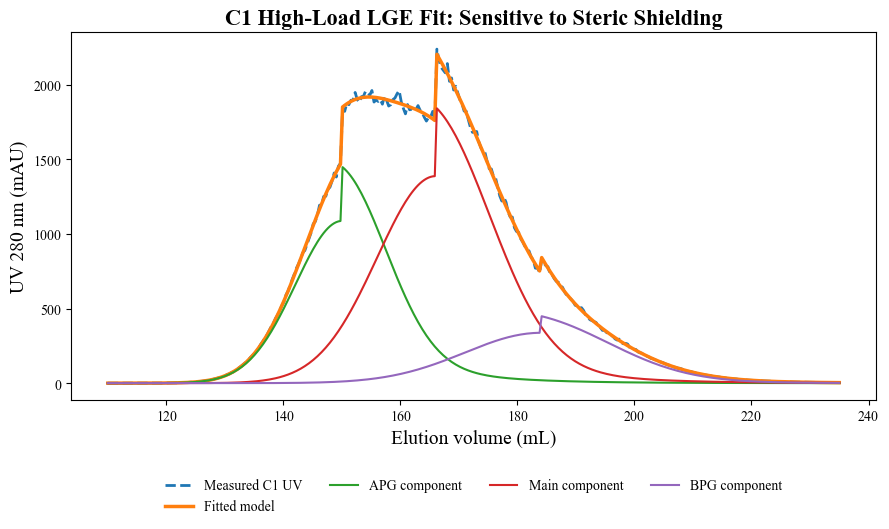

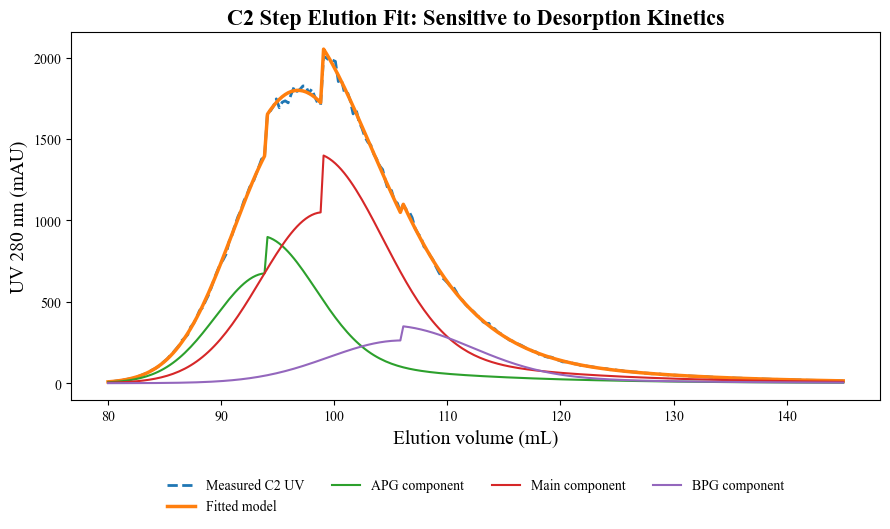

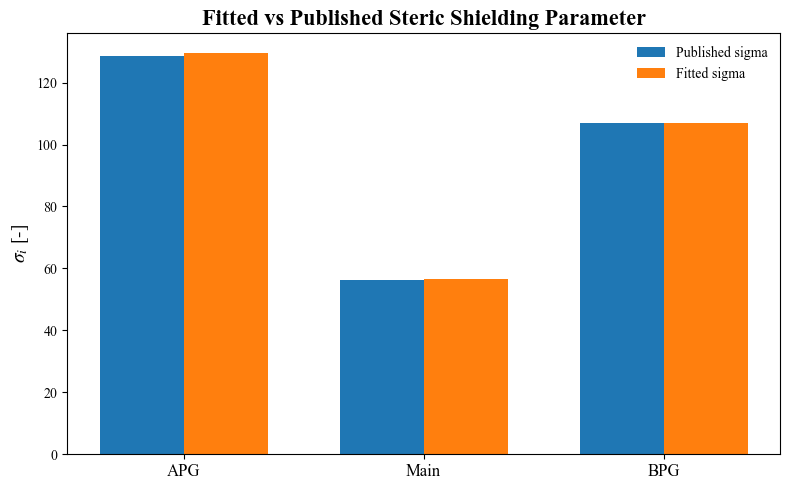

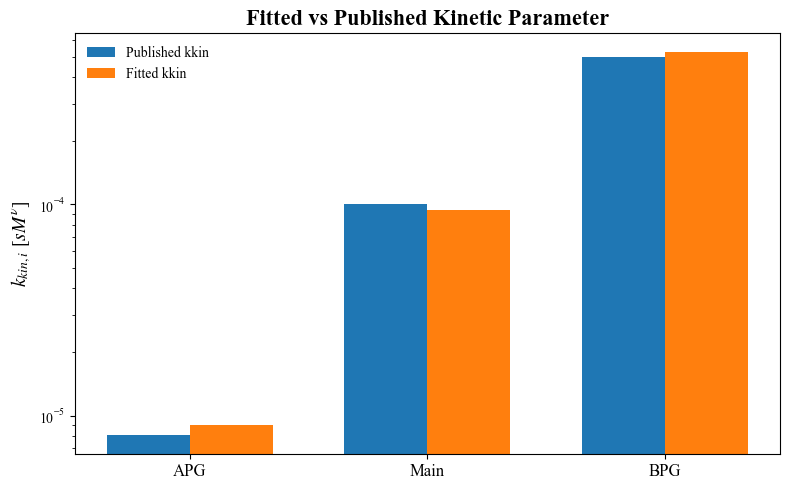

In [2]:
"""
Representative inverse estimation of nonlinear SMA parameters:
    kkin_i and sigma_i

This code demonstrates the logic used in Saleh et al.:
1. Use fixed nu_i and keq_i from Yamamoto analysis.
2. Use C1 high-load LGE + C2 step elution chromatograms.
3. Fit remaining nonlinear parameters kkin_i and sigma_i by least squares.

Important:
- This is a representative educational implementation.
- It is not a full ChromX/CADET transport-dispersive PDE solver.
- Replace the synthetic data with digitized C1/C2 chromatogram CSV files
  to use your own experimental data.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from pathlib import Path

# -----------------------------
# 1. Published fixed parameters
# -----------------------------
species = ["APG", "Main", "BPG"]

nu = {
    "APG": 7.38,
    "Main": 7.50,
    "BPG": 7.70,
}

keq = {
    "APG": 1.45,
    "Main": 1.41,
    "BPG": 1.69,
}

# Published final values at pH 5.8, used here to generate demo data
true_params = {
    "APG": {"kkin": 8.08e-6, "sigma": 128.6},
    "Main": {"kkin": 1.00e-4, "sigma": 56.3},
    "BPG": {"kkin": 5.00e-4, "sigma": 107.1},
}

# -----------------------------
# 2. Representative peak model
# -----------------------------
def skewed_peak(volume, center, width, area, tail):
    """
    Simple skewed peak function.
    This is a surrogate for chromatographic peak shape.

    center: retention volume
    width: peak width
    area: peak intensity
    tail: tailing factor
    """
    gaussian = np.exp(-0.5 * ((volume - center) / width) ** 2)

    tail_part = np.exp(-(volume - center) / tail)
    tail_part[volume < center] = 0

    peak = 0.75 * gaussian + 0.25 * tail_part
    return area * peak


def simulate_experiment(volume, params_vector, experiment="C1"):
    """
    Simulates UV chromatogram from kkin and sigma values.

    params_vector:
        [log10(kkin_APG), sigma_APG,
         log10(kkin_Main), sigma_Main,
         log10(kkin_BPG), sigma_BPG]
    """

    p = {}
    for i, sp in enumerate(species):
        p[sp] = {
            "kkin": 10 ** params_vector[2 * i],
            "sigma": params_vector[2 * i + 1],
        }

    signal_total = np.zeros_like(volume)
    components = {}

    for sp in species:
        kkin_i = p[sp]["kkin"]
        sigma_i = p[sp]["sigma"]

        # Retention affected by binding strength and shielding
        # Larger sigma gives stronger nonlinear shift in overloaded LGE.
        base_center = {"APG": 150, "Main": 166, "BPG": 184}[sp]

        if experiment == "C1":
            # High-load LGE: more sensitive to sigma
            center = base_center + 0.045 * (sigma_i - true_params[sp]["sigma"])
            width = {"APG": 8, "Main": 10, "BPG": 13}[sp]
            area = {"APG": 1450, "Main": 1850, "BPG": 450}[sp]

        elif experiment == "C2":
            # Step elution: less sigma-sensitive
            center = {"APG": 94, "Main": 99, "BPG": 106}[sp]
            center = center + 0.010 * (sigma_i - true_params[sp]["sigma"])
            width = {"APG": 4.5, "Main": 5.5, "BPG": 6.5}[sp]
            area = {"APG": 900, "Main": 1400, "BPG": 350}[sp]

        else:
            raise ValueError("experiment must be 'C1' or 'C2'")

        # kkin controls peak tailing
        # smaller kkin = larger tailing
        k_ref = true_params[sp]["kkin"]
        tail = 12 * (k_ref / kkin_i) ** 0.35
        tail = np.clip(tail, 4, 45)

        comp = skewed_peak(volume, center, width, area, tail)
        components[sp] = comp
        signal_total += comp

    # UV detector saturation in the paper was 3000 mAU
    signal_total = np.minimum(signal_total, 3000)

    return signal_total, components


# -----------------------------
# 3. Load or generate data
# -----------------------------
def make_demo_data():
    rng = np.random.default_rng(42)

    vol_C1 = np.linspace(110, 235, 350)
    vol_C2 = np.linspace(80, 145, 250)

    p_true = []
    for sp in species:
        p_true.extend([
            np.log10(true_params[sp]["kkin"]),
            true_params[sp]["sigma"]
        ])
    p_true = np.array(p_true)

    uv_C1, comp_C1 = simulate_experiment(vol_C1, p_true, "C1")
    uv_C2, comp_C2 = simulate_experiment(vol_C2, p_true, "C2")

    uv_C1_meas = uv_C1 * (1 + rng.normal(0, 0.015, size=uv_C1.size))
    uv_C2_meas = uv_C2 * (1 + rng.normal(0, 0.015, size=uv_C2.size))

    return vol_C1, uv_C1_meas, vol_C2, uv_C2_meas


# Use this if you digitize Figure 2 manually:
# C1_csv = pd.read_csv("C1_digitized.csv")  # columns: volume_mL, uv_mAU
# C2_csv = pd.read_csv("C2_digitized.csv")  # columns: volume_mL, uv_mAU
# vol_C1, uv_C1_meas = C1_csv["volume_mL"].values, C1_csv["uv_mAU"].values
# vol_C2, uv_C2_meas = C2_csv["volume_mL"].values, C2_csv["uv_mAU"].values

vol_C1, uv_C1_meas, vol_C2, uv_C2_meas = make_demo_data()

# -----------------------------
# 4. Least-squares objective
# -----------------------------
def residuals(params_vector):
    pred_C1, _ = simulate_experiment(vol_C1, params_vector, "C1")
    pred_C2, _ = simulate_experiment(vol_C2, params_vector, "C2")

    # Normalize residuals so C1 and C2 contribute similarly
    r1 = (pred_C1 - uv_C1_meas) / np.max(uv_C1_meas)
    r2 = (pred_C2 - uv_C2_meas) / np.max(uv_C2_meas)

    return np.concatenate([r1, r2])


# -----------------------------
# 5. Initial guesses and bounds
# -----------------------------
# Guess values intentionally not equal to published values
x0 = np.array([
    np.log10(2e-5), 80,     # APG
    np.log10(5e-5), 80,     # Main
    np.log10(2e-4), 80,     # BPG
])

lower = np.array([
    -7.0, 0,
    -7.0, 0,
    -7.0, 0,
])

upper = np.array([
    -2.5, 200,
    -2.5, 200,
    -2.5, 200,
])

fit = least_squares(
    residuals,
    x0,
    bounds=(lower, upper),
    method="trf",
    max_nfev=5000
)

# -----------------------------
# 6. Extract fitted parameters
# -----------------------------
fitted = {}
for i, sp in enumerate(species):
    fitted[sp] = {
        "kkin_fit": 10 ** fit.x[2 * i],
        "sigma_fit": fit.x[2 * i + 1],
        "kkin_published": true_params[sp]["kkin"],
        "sigma_published": true_params[sp]["sigma"],
    }

results = pd.DataFrame(fitted).T
print(results)

# -----------------------------
# 7. Plot fits
# -----------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

outdir = Path("inverse_estimation_outputs")
outdir.mkdir(exist_ok=True)

pred_C1, comp_C1 = simulate_experiment(vol_C1, fit.x, "C1")
pred_C2, comp_C2 = simulate_experiment(vol_C2, fit.x, "C2")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(vol_C1, uv_C1_meas, "--", linewidth=2, label="Measured C1 UV")
ax.plot(vol_C1, pred_C1, linewidth=2.5, label="Fitted model")
for sp in species:
    ax.plot(vol_C1, comp_C1[sp], linewidth=1.5, label=f"{sp} component")

ax.set_title("C1 High-Load LGE Fit: Sensitive to Steric Shielding", fontsize=16, fontweight="bold")
ax.set_xlabel("Elution volume (mL)", fontsize=14)
ax.set_ylabel("UV 280 nm (mAU)", fontsize=14)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False)
ax.grid(False)
plt.tight_layout()
plt.savefig(outdir / "C1_inverse_fit.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(vol_C2, uv_C2_meas, "--", linewidth=2, label="Measured C2 UV")
ax.plot(vol_C2, pred_C2, linewidth=2.5, label="Fitted model")
for sp in species:
    ax.plot(vol_C2, comp_C2[sp], linewidth=1.5, label=f"{sp} component")

ax.set_title("C2 Step Elution Fit: Sensitive to Desorption Kinetics", fontsize=16, fontweight="bold")
ax.set_xlabel("Elution volume (mL)", fontsize=14)
ax.set_ylabel("UV 280 nm (mAU)", fontsize=14)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False)
ax.grid(False)
plt.tight_layout()
plt.savefig(outdir / "C2_inverse_fit.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 8. Parameter comparison plot
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(species))
width = 0.35

ax.bar(x - width/2, results["sigma_published"], width, label="Published sigma")
ax.bar(x + width/2, results["sigma_fit"], width, label="Fitted sigma")

ax.set_xticks(x)
ax.set_xticklabels(species, fontsize=12)
ax.set_ylabel(r"$\sigma_i$ [-]", fontsize=14)
ax.set_title("Fitted vs Published Steric Shielding Parameter", fontsize=16, fontweight="bold")
ax.legend(frameon=False)
ax.grid(False)

plt.tight_layout()
plt.savefig(outdir / "sigma_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, results["kkin_published"], width, label="Published kkin")
ax.bar(x + width/2, results["kkin_fit"], width, label="Fitted kkin")

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(species, fontsize=12)
ax.set_ylabel(r"$k_{kin,i}$ [$sM^\nu$]", fontsize=14)
ax.set_title("Fitted vs Published Kinetic Parameter", fontsize=16, fontweight="bold")
ax.legend(frameon=False)
ax.grid(False)

plt.tight_layout()
plt.savefig(outdir / "kkin_comparison.png", dpi=300, bbox_inches="tight")
plt.show()